In [36]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from math import pi, sqrt
from scipy.optimize import least_squares

## Constants

In [37]:
# param
ODE_SOLVE_METHOD = 'RK45'  # 'Radau', 'BDF', 'LSODA', 'RK45', etc.

# --- Physical constants ---
h = 6.62607015e-34        # Planck constant, J·s
e_charge = 1.602176634e-19  # Elementary charge, C
hbar = h / (2 * np.pi)    # Reduced Planck constant, J·s
k_B = 1.380649e-23        # Boltzmann constant, J/K
c = 299792458.0           # Speed of light, m/s
epsilon_0 = 8.854187817e-12 # Vacuum permittivity, F/m
amu = 1.66053906660e-27   # Atomic mass unit, kg

# --- Transition parameters of R(56) 32–0 (assumed to be the a10 hyperfine peak) ---
k_a_10 = 18788.348        # cm-1
f_a_10 = k_a_10 * c * 100  # Hz
# f_a_1_to_a_10 = 571e6 # Hz, a1 to a10 hyperfine splitting
print(f"a10 wavelength λ = {c/f_a_10*1e9:.2f} nm")
linewidth = 37e6

# Rb vapor number density (low-pressure) (assumed)
T = 273.15 + 28 # K
L_cell = 5
P_mbar = 0.05 # 10^-1 to 10^-2 mbar
P_Pa = P_mbar * 100 # convert to Pascals
N = P_Pa / (k_B * T)  # ideal gas law, m^-3
print(f"I2 vapor number density N = {N/1e16:.2f} x10^16 m^-3 at T = {T:.2f} K")

D_mode = 31e-6 # m, beam diameter at the PMC
A_mode = pi * (D_mode/2)**2 # m^2, beam area at the PMC
print(f"Beam area A = {A_mode*1e12:.2f} μm^2 at the PMC")

# in power
P_tot = 7e-3
PBS_ratio = 1/9 # 1 : 9 probe to pump power ratio
P_probe = P_tot * 1/(1 + 1/PBS_ratio) / 2 * 0.25 / 2 / 2# /2 for the second PBS, 0.25 for the coupling efficiency to the PMC, /2 again for the PBS before PD1
print(f"Probe to total ratio = 1 : {P_tot/P_probe:.1f}, P_probe = {P_probe*1e3:.2f} mW")

# pump
# P_pump = P_tot * (1/PBS_ratio) / (1 + 1/PBS_ratio) /4 /2 * 0.5 # /4 for the second two layers PBS, /2 for the trird PBS, 0.5 for the coupling efficiency to the PMC
P_pump = P_tot *0.5
print(f"Pump to total ratio = 1 : {P_tot/P_pump:.1f}, P_pump = {P_pump*1e3:.2f} mW")

# alpha of iodine
sigma = 3.03e-18 * 1e-4

mod_depth = 1

a10 wavelength λ = 532.24 nm
I2 vapor number density N = 120255.20 x10^16 m^-3 at T = 301.15 K
Beam area A = 754.77 μm^2 at the PMC
Probe to total ratio = 1 : 320.0, P_probe = 0.02 mW
Pump to total ratio = 1 : 2.0, P_pump = 3.50 mW


## Data unnormalization

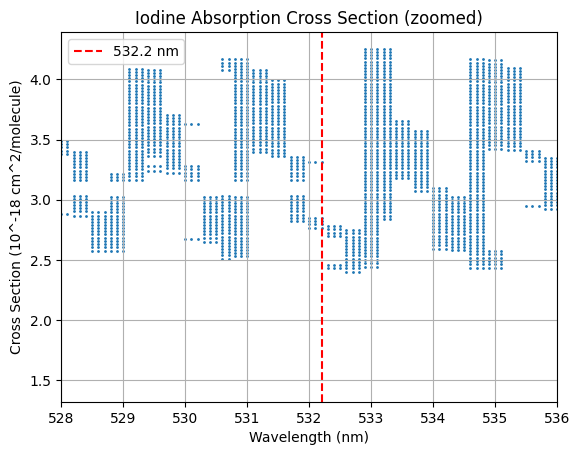

Average cross section around 532.2 nm: 2.91e+00e-18 cm^2/molecule


In [38]:
# graph
filename = "../../fig_to_txt/I2 cross section.csv"
data = np.loadtxt(filename, delimiter=',')

plt.figure()
plt.scatter(data[:, 0], data[:, 1], s=1)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Cross Section (10^-18 cm^2/molecule)')
plt.title('Iodine Absorption Cross Section (zoomed)')
plt.grid()
plt.xlim(528, 536)
# red vertical line at 532.2 nm
plt.axvline(x=532.2, color='r', linestyle='--', label='532.2 nm')
plt.legend()
plt.show()

# taking the average cross section around 532.2 nm (+- 0.1 nm)
wavelengths = data[:, 0]
cross_sections = data[:, 1]
mask = (wavelengths >= 532.1) & (wavelengths <= 532.3)
avg_cross_section = np.mean(cross_sections[mask]) * 1e-18
print(f"Average cross section around 532.2 nm: {avg_cross_section / 1e-18:.2e}e-18 cm^2/molecule")

Reference frequency f_ref = 152.460 MHz
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.0665e+01                                    1.75e+01    
       1              2         1.2288e+00      9.44e+00       2.03e+07       6.81e+00    
       2              3         4.8999e-01      7.39e-01       2.39e+07       7.78e-01    
       3              4         2.0911e-01      2.81e-01       1.94e+07       1.12e+00    
       4              5         1.5157e-01      5.75e-02       1.43e+07       4.15e-01    
       5              6         1.3272e-01      1.88e-02       1.02e+07       1.76e-01    
       6              7         1.2956e-01      3.16e-03       4.07e+06       5.48e-02    
       7              8         1.2487e-01      4.69e-03       1.15e+07       1.32e+00    
       8              9         1.1690e-01      7.97e-03       2.51e+06       2.32e-01    
       9             10         1.0917e-01      7.

c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\optimize\_lsq\least_squares.py:905: UserWarning: Setting `xtol` below the machine epsilon (2.22e-16) effectively disables the corresponding termination condition.
  ftol, xtol, gtol = check_tolerance(ftol, xtol, gtol, method)


      22             24         8.6864e-02      2.19e-03       3.16e+06       9.27e-02    
      23             25         8.2550e-02      4.31e-03       6.13e+06       6.32e-02    
      24             26         7.7584e-02      4.97e-03       1.09e+07       6.08e-01    
      25             27         7.4422e-02      3.16e-03       1.55e+06       2.57e-01    
      26             28         7.2582e-02      1.84e-03       3.07e+06       1.23e-01    
      27             29         7.1927e-02      6.54e-04       2.56e+06       1.25e-01    
      28             30         7.1913e-02      1.42e-05       4.11e+04       2.23e-02    
      29             31         7.1747e-02      1.66e-04       1.07e+06       9.63e-03    
      30             32         7.1745e-02      1.88e-06       2.37e+04       2.04e-02    
      31             33         7.1705e-02      4.05e-05       4.97e+05       1.50e-04    
      32             34         7.1699e-02      5.74e-06       2.17e+05       9.53e-04    

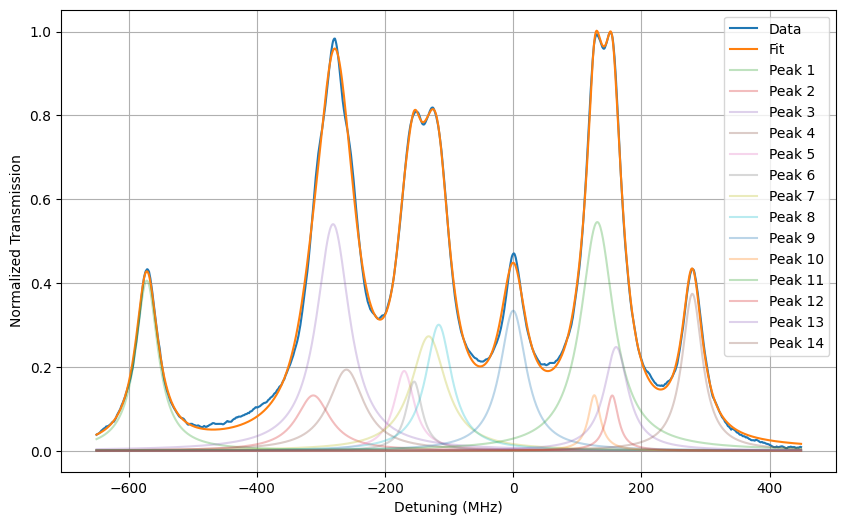

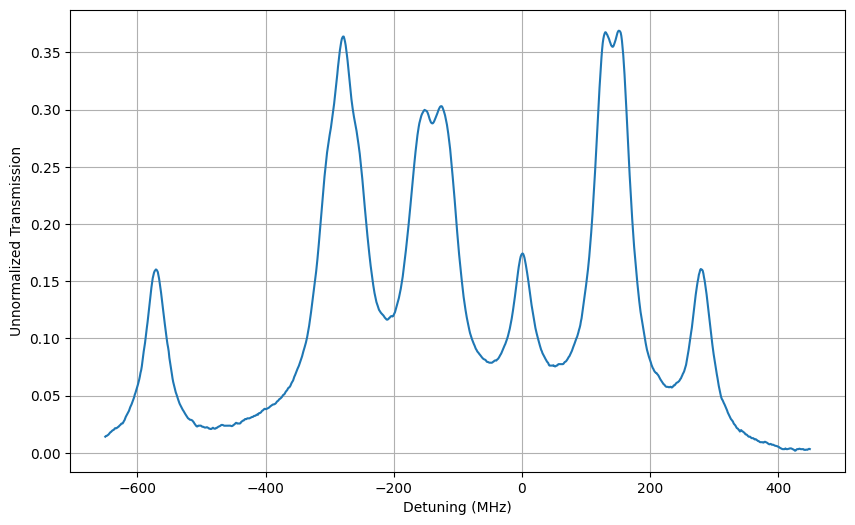

In [39]:
# ============================================================
# LOAD DATA
# ============================================================

# CSV should contain:
# column 0 = detuning (MHz)
# column 1 = normalized transmission

filename = "../../fig_to_txt/I2 hyperfine.csv"
data = np.loadtxt(filename, delimiter=',')

f_data_MHz = data[:, 0]
T_data = data[:, 1]

# Convert MHz -> Hz
f_data = f_data_MHz * 1e6

# ============================================================
# PEAK CENTERS
# ============================================================

# Example:
# 14 peak centers (in kHz)

f_peaks_kHz = np.array([
    563259651971, # original a1
    # 563260223513 - 570580, # a1, from Wang's data
    563259911669, # a2
    # 563260223513 - 307410,
    563260223513 - 280980, # either a3 or a4, from Wang
    563259963337, # a5
    # 563260223513 - 255730,
    563260053449,
    # 563260223513 - 166420,
    563260068965,
    # 563260223513 - 152000,
    563260091597,
    # 563260223513 - 129470,
    563260107314,
    # 563260223513 - 139600,
    563260223513, # a10
    563260350026,
    # 563260223513 + 123300,
    563260354725,
    # 563260223513 + 127700,
    563260378001,
    # 563260223513 + 149890,
    563260384178,
    # 563260223513 + 156550,
    # 563260509925, # original a15
    563260223513 + 279400 # from Wang's data
])

# Convert to Hz
f_peaks = f_peaks_kHz * 1e3
# convert to detuning from a10
f_peaks -= f_peaks[8] # a10 is the 10th peak (index 8)

n_peaks = len(f_peaks)

# ============================================================
# KNOWN CONSTANTS
# ============================================================

alpha0 =  avg_cross_section / 1e4 * N # convert cm^2 to m^2

# reference normalization point:
# f_ref = f_peaks[12]   # a14
f_ref = (152460) * 1e3
print(f"Reference frequency f_ref = {f_ref/1e6:.3f} MHz")

# ============================================================
# LORENTZIAN
# ============================================================

def lorentzian(f, f0, gamma):
    return (gamma/2)**2 / ((f-f0)**2 + (gamma/2)**2)

# ============================================================
# MODEL
# ============================================================

def transmission_model(params, f):

    # unpack
    K = params[:n_peaks]
    Gamma = params[n_peaks:]

    # build exponent
    S = np.zeros_like(f)

    for i in range(n_peaks):
        S += K[i] * lorentzian(f, f_peaks[i], Gamma[i])

    exponent = alpha0 * L_cell * S

    # normalization reference
    S_ref = 0

    for i in range(n_peaks):
        S_ref += K[i] * lorentzian(
            f_ref,
            f_peaks[i],
            Gamma[i]
        )

    exponent_ref = alpha0 * L_cell * S_ref

    numerator = np.exp(exponent) - 1
    denominator = np.exp(exponent_ref) - 1

    return numerator / denominator

# ============================================================
# RESIDUALS
# ============================================================

def residuals(params):
    return transmission_model(params, f_data) - T_data

# ============================================================
# INITIAL GUESS
# ============================================================

K0 = np.ones(n_peaks) * 0.29289 # stable: 1e-6

# 20 MHz initial linewidth
Gamma0 = np.ones(n_peaks) * 47e6

p0 = np.concatenate([K0, Gamma0])

# ============================================================
# BOUNDS
# ============================================================

lower_K = np.ones(n_peaks) * 0.075 # stable: 7e-7

# linewidth > 0
lower_Gamma = np.ones(n_peaks) * 20e6 # stable: 20e6

upper_K = np.ones(n_peaks) * 1 # stable: 1e-5

# below 200 MHz
upper_Gamma = np.ones(n_peaks) * 70e6 # stable: 100e6

lower = np.concatenate([lower_K, lower_Gamma])
upper = np.concatenate([upper_K, upper_Gamma])

# ============================================================
# FIT
# ============================================================

result = least_squares(
    residuals,
    p0,
    bounds=(lower, upper),
    verbose=2,
    xtol=1e-20
)

params_fit = result.x

K_fit = params_fit[:n_peaks]
Gamma_fit = params_fit[n_peaks:]

# ============================================================
# FITTED CURVE
# ============================================================

T_fit = transmission_model(params_fit, f_data)


# ============================================================
# PRINT PARAMETERS
# ============================================================

print("\nFitted Parameters:\n")

for i in range(n_peaks):

    print(
        f"Peak {i+1}: "
        f"K = {K_fit[i]:.5g}, "
        f"Gamma = {Gamma_fit[i]/1e6:.3f} MHz"
    )

# ============================================================
# UNNORMALIZED TRANSMISSION
# ============================================================
Nk = (np.exp(alpha0 * L_cell * np.sum(K_fit * lorentzian(f_ref, f_peaks, Gamma_fit))) - 1)**(-1)
Normalization_factor = Nk / np.exp(- alpha0 * L_cell)

Normalization_factor = 1/0.37006457219858424 # from original method
print(f"\nNormalization factor: {Normalization_factor:.4f}")
T_unnorm = T_data / Normalization_factor

# ============================================================
# PLOT NORMALIZED
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    f_data_MHz,
    T_data,
    label="Data"
)

plt.plot(
    f_data_MHz,
    T_fit,
    label="Fit"
)

# plot per peak contributions
for i in range(n_peaks):
    T_peak = Nk * (np.exp(alpha0 * L_cell * K_fit[i] * lorentzian(f_data, f_peaks[i], Gamma_fit[i])) - 1)
    
    # if(i==0):
    #     T_peak = Nk * (np.exp(alpha0 * L_cell * (K_fit[i] + 1e-6) * lorentzian(f_data, f_peaks[i], Gamma_fit[i])) - 1)

    # 30% transparancy
    plt.plot(
        f_data_MHz,
        T_peak,
        alpha=0.3, 
        label=f"Peak {i+1}"
    )

plt.xlabel("Detuning (MHz)")
plt.ylabel("Normalized Transmission")

plt.legend()
plt.grid()

plt.show()

# ============================================================
# PLOT UNNORMALIZED
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    f_data_MHz,
    T_unnorm
)

plt.xlabel("Detuning (MHz)")
plt.ylabel("Unnormalized Transmission")

plt.grid()

plt.show()

In [40]:
# finding effective I_sat for a1
# using simple two level model
# K = 1 - (1 + I_pu / I_sat)^(-1/2)

K_ref = 1 - (1 + 1)**(-1/2)
print(f"Expected K at I_pu = I_sat: {K_ref:.5f}")

I_pu = P_pump / A_mode
# I_sat = I_pu / ((1 - K_fit[0])**(-2) - 1)
I_sat = I_pu / ((1 - K_ref)**(-2) - 1)
print(f"Estimated I_sat for a1: {I_sat:.2f} W/m^2")

D_plan = 1e-3  # m, planar beam diameter
A_plan = pi * (D_plan/2)**2  # m^2, planar beam area
P_mbar_plan = 4
P_sat_plan = I_sat * A_plan
print(f"Estimated P_sat: {I_sat * A_mode*1e3:.2f} mW")
print(f"Estimated planned P_sat: {P_sat_plan*1e3:.2f} mW")



Expected K at I_pu = I_sat: 0.29289
Estimated I_sat for a1: 4637188.77 W/m^2
Estimated P_sat: 3.50 mW
Estimated planned P_sat: 3642.04 mW


## Statistical noise
- Intensity-derived noise
    - photon detector noise
    - power supply noise
- Atom number-derived noise
    - quantum projection 
    - gas density
    - photon shot

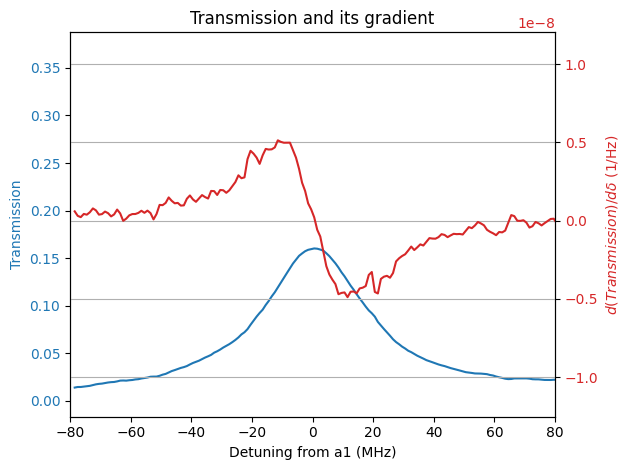

max gradient at detuning 11.54 MHz
min gradient at detuning -11.46 MHz
peak-to-peak gradient distance: 23.00 MHz
modulation frequency 60.00 MHz
bellow is the plot of the error signal generated by modulating the laser at this frequency


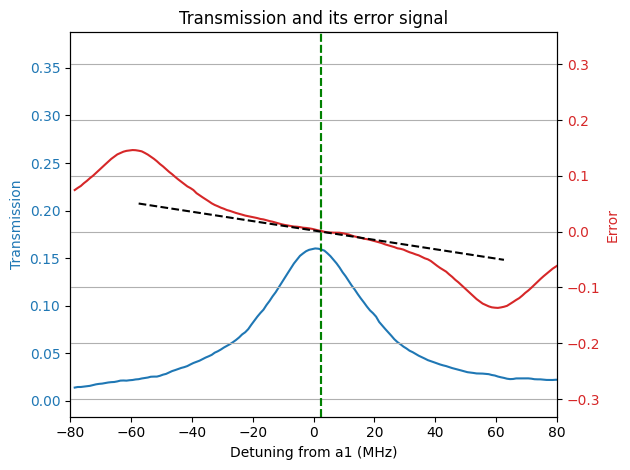

Zero-crossing detuning: 2.54 MHz
center detuning: 0.04 MHz
f0 = 563.259934 THz
dT/dDelta at zero-crossing: -8.40e-10 1/Hz


In [41]:
# f0= f_peaks[0] # in Hz
f_a_1_to_a_10 = (f_peaks[8] - f_peaks[0]) # in Hz

# Error characterization

delta_array_MHz = f_data_MHz
Transm = T_unnorm
# print(delta_array_MHz)
# print(Transm)

# Transmission with its gradient
dTransm_dDelta = np.gradient(Transm, delta_array_MHz * 1e6)  # convert MHz to Hz for the gradient calculation
# print(dTransm_dDelta)
fig, ax1 = plt.subplots()
color = 'tab:blue'
ax1.set_xlabel(r"Detuning from a1 (MHz)")
ax1.set_ylabel(r"Transmission", color=color)
ax1.plot(delta_array_MHz + f_a_1_to_a_10/1e6, Transm, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel(r"$d(Transmission)/d\delta$ (1/Hz)", color=color)  # we already handled the x-label with ax1
ax2.plot(delta_array_MHz + f_a_1_to_a_10/1e6, dTransm_dDelta, color=color)
ax2.tick_params(axis='y', labelcolor=color)
plt.title('Transmission and its gradient')
plt.xlim(-80, 80)  # zoom in on the Lamb dip region
plt.grid()
plt.tight_layout()
plt.show()

# finding the point of max gradient and min gradient, and their detuning distance, for delta > 0 (taking the right dip)
delta_mask = delta_array_MHz + 3/5 * f_a_1_to_a_10/1e6 < 0
max_gradient_index = np.argmin(dTransm_dDelta[delta_mask])
min_gradient_index = np.argmax(dTransm_dDelta[delta_mask]) 
print(f"max gradient at detuning {delta_array_MHz[max_gradient_index] + f_a_1_to_a_10/1e6:.2f} MHz")
print(f"min gradient at detuning {delta_array_MHz[min_gradient_index] + f_a_1_to_a_10/1e6:.2f} MHz")
max_gradient_detuning = delta_array_MHz[max_gradient_index] + f_a_1_to_a_10/1e6
min_gradient_detuning = delta_array_MHz[min_gradient_index] + f_a_1_to_a_10/1e6
gradient_distance = max_gradient_detuning - min_gradient_detuning
print(f"peak-to-peak gradient distance: {gradient_distance:.2f} MHz")

# mod_frequency = gradient_distance / 2
mod_frequency = 60 # from paper
print(f"modulation frequency {mod_frequency:.2f} MHz")
print("bellow is the plot of the error signal generated by modulating the laser at this frequency")

# plot the transmission with error signal from the modulation
def Transm_Error(x, delta_array_MHz, Transm, mod=mod_frequency):
    if(x - mod < delta_array_MHz[0]):
        return np.interp(x + mod, delta_array_MHz, Transm) - Transm[0]  # assume the same value for out-of-bounds
    elif(x + mod > delta_array_MHz[-1]):
        return Transm[-1] - np.interp(x - mod, delta_array_MHz, Transm) 
    return np.interp(x + mod, delta_array_MHz, Transm) - np.interp(x - mod, delta_array_MHz, Transm)
Error = []
for x in delta_array_MHz:
    Error.append(Transm_Error(x, delta_array_MHz, Transm, mod=mod_frequency))  # taking the difference between Transm at f+mod_frequency and f-mod_frequency detuning points
Error = np.array(Error)

fig, ax1 = plt.subplots()
color = 'tab:blue'
ax1.set_xlabel(r"Detuning from a1 (MHz)")
ax1.set_ylabel(r"Transmission", color=color)
ax1.plot(delta_array_MHz + f_a_1_to_a_10/1e6, Transm, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel(r"Error", color=color)  # we already handled the x-label with ax1
ax2.plot(delta_array_MHz + f_a_1_to_a_10/1e6, Error, color=color)
ax2.tick_params(axis='y', labelcolor=color)
# marking the zero-crossing point of the error signal within the range of grad min and max
error_mask = (delta_array_MHz + f_a_1_to_a_10/1e6 > min_gradient_detuning) & (delta_array_MHz + f_a_1_to_a_10/1e6 < max_gradient_detuning)
zero_crossing_indices = np.where(np.diff(np.sign(Error[error_mask])))[0] + np.where(error_mask)[0][0]  # adjust indices to match the original array
for idx in zero_crossing_indices:
    if min_gradient_detuning < delta_array_MHz[idx] + f_a_1_to_a_10/1e6 < max_gradient_detuning:
        plt.axvline(x=delta_array_MHz[idx] + f_a_1_to_a_10/1e6, color='green', linestyle='--', label='Zero-crossing point')
        break
plt.axvline(x=delta_array_MHz[idx] + f_a_1_to_a_10/1e6, color='green', linestyle='--', label='Zero-crossing point')

# marking the tangent line at the zero-crossing point, the tangent is calculated using the slope (linear regression) from max gradient index to min gradient index
# tangent_slope = (Error[idx+1] - Error[idx-1]) / ((delta_array_MHz[idx+1] - delta_array_MHz[idx-1]) * 1e6)  # in 1/Hz
start_gradient_index = min(min_gradient_index, max_gradient_index)
end_gradient_index   = max(min_gradient_index, max_gradient_index)
# x in Hz
x = delta_array_MHz[start_gradient_index:end_gradient_index] * 1e6
# y
y = Error[start_gradient_index:end_gradient_index]
# linear regression
slope, intercept = np.polyfit(x, y, 1)
tangent_slope = slope  # in 1/Hz

tangent_x = np.linspace(delta_array_MHz[idx] - mod_frequency, delta_array_MHz[idx] + mod_frequency, 100)
tangent_y = tangent_slope * 1e6 * (tangent_x - (delta_array_MHz[idx]))
plt.plot(tangent_x + f_a_1_to_a_10/1e6, tangent_y, color='black', linestyle='--', label='Tangent at zero-crossing')
plt.title('Transmission and its error signal')
plt.xlim(-80, 80)  # zoom in on the Lamb dip region
plt.grid()
plt.tight_layout()
plt.show()
f0 = (delta_array_MHz[idx])*1e6 + f_a_10  # convert MHz to Hz
print(f"Zero-crossing detuning: {delta_array_MHz[idx] + f_a_1_to_a_10/1e6:.2f} MHz")
print(f"center detuning: {(max_gradient_detuning + min_gradient_detuning)/2:.2f} MHz")
print(f"f0 = {f0/1e12:f} THz")
print(f"dT/dDelta at zero-crossing: {tangent_slope:.2e} 1/Hz")


### Probe intensity-derived noise - PD noise

### Probe intensity-derived noise - Shot noise
simple version

quantum efficiency eta: 0.89
Min transmission: 0.1193, Max transmission: 0.1261, Mean transmission: 0.1227


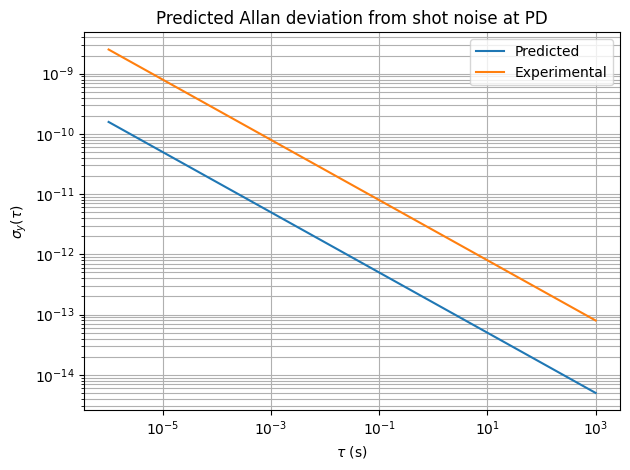

uncertainty f in 1 s: 0.08743673095235968 kHz Normalized: 1.552333579843441e-13
ref uncertainty in 1 s: 1.394991984459191 kHz Normalized: 2.476639825736761e-12


In [42]:
photo_sens = 0.57  # A/W, from S5972 datasheet, at around 800 nm wavelength

Area =  np.pi * (D_mode/2)**2  # in W, where D_mode is the probe beam diameter in meters (asssumed to be the same as the D in PMC)

tau = np.logspace(-6, 3, 200)  # 1 us to 10 s
# eta = h * f0 / e_charge * photo_sens
eta = 0.89 # asssume the same quantum efficiency as the S5972 photodetector 
print(f"quantum efficiency eta: {eta:.2f}")
mean_Transm = (Transm[max_gradient_index] + Transm[min_gradient_index]) / 2
print(f"Min transmission: {Transm[min_gradient_index]:.4f}, Max transmission: {Transm[max_gradient_index]:.4f}, Mean transmission: {mean_Transm:.4f}")
P_det = mean_Transm * P_probe # in W
sigma_I_det = np.sqrt((eta * h * f0 * P_det) / (tau))  
sigma_y_shot = np.sqrt(3) * sigma_I_det / (f0 * P_probe * np.abs(tangent_slope)) 

sigma_y_shot_ref = 2.52e-12 / np.sqrt(tau)  # from the paper, in normalized units
plt.figure()
plt.loglog(tau, sigma_y_shot, label='Predicted')
plt.loglog(tau, sigma_y_shot_ref, label='Experimental')
plt.xlabel(r'$\tau$ (s)')
plt.ylabel(r'$\sigma_y(\tau)$')
plt.grid(True, which='both')
plt.title(f'Predicted Allan deviation from shot noise at PD')
plt.legend()
plt.tight_layout()
plt.show()

print("uncertainty f in 1 s:", f0 * sigma_y_shot[np.argmin(np.abs(tau - 1.0))] / 1e3, "kHz", "Normalized:", sigma_y_shot[np.argmin(np.abs(tau - 1.0))])
print("ref uncertainty in 1 s:", sigma_y_shot_ref[np.argmin(np.abs(tau - 1.0))] * f0 / 1e3, "kHz", "Normalized:", sigma_y_shot_ref[np.argmin(np.abs(tau - 1.0))])

detailed version

quantum efficiency eta: 0.89
Min transmission: 0.1193, Max transmission: 0.1261, Mean transmission: 0.1227
center transmission T0: 0.1599


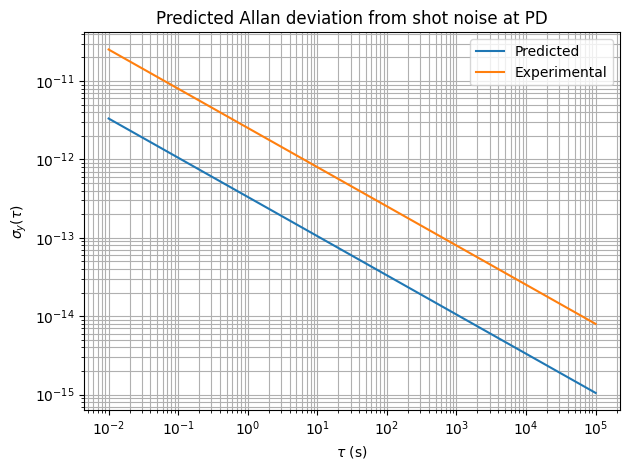

uncertainty f in 1 s: 0.18594465143970584 kHz Normalized: 3.3012227616264694e-13
ref uncertainty in 1 s: 1.4112268729483495 kHz Normalized: 2.5054629099168706e-12


In [43]:
photo_sens = 0.57  # A/W, from S5972 datasheet, at around 800 nm wavelength
Area =  np.pi * (D_mode/2)**2  # in W, where D_mode is the probe beam diameter in meters (asssumed to be the same as the D in PMC)
I_refl = 0.007e-3 / Area # from manual calculation
avg_sin_phi = 2 / np.pi

tau = np.logspace(-2, 5, 200)  # 1 us to 10 s
# eta = h * f0 / e_charge * photo_sens
eta = 0.89 # asssume the same quantum efficiency as the S5972 photodetector 
print(f"quantum efficiency eta: {eta:.2f}")
mean_Transm = (Transm[max_gradient_index] + Transm[min_gradient_index]) / 2
T0 = np.interp(0, delta_array_MHz + f_a_1_to_a_10/1e6, Transm)  # transmission at 0 detuning, from the graph
print(f"Min transmission: {Transm[min_gradient_index]:.4f}, Max transmission: {Transm[max_gradient_index]:.4f}, Mean transmission: {mean_Transm:.4f}")
print(f"center transmission T0: {T0:.4f}")

# powers
P_s = P_probe * mod_depth**2 / 4 # in W
I_s = P_s / Area # in W/m^2
I_0 = P_probe / Area # in W/m^2
E2_to_I = 1/2 * c * epsilon_0

# sigma_I^2 
sigma2_I_s = (eta * h * f0 * mean_Transm * (I_s / Area)) / (tau)
sigma2_I_r = (eta * h * f0 * (I_refl / Area)) / (tau)

# partal derivatives of V
dV_dT_s_min_GB = (1 / (2 * np.sqrt(mean_Transm))) * avg_sin_phi * (I_0 * np.sqrt(T0) + np.sqrt(I_refl * I_0))
dV_dIr_min_GB = np.sqrt(I_0 / I_refl) * avg_sin_phi**2 * np.sqrt(mean_Transm)
sigma2_V_min_GB = ((2 / (I_0 * mod_depth**2 / 4)**2 * dV_dT_s_min_GB**2 * sigma2_I_s) + dV_dIr_min_GB**2 * sigma2_I_r) / (E2_to_I**2)

dV_df_min_GB = ((I_0 * np.sqrt(T0) + np.sqrt(I_refl * I_0) * avg_sin_phi) * avg_sin_phi * tangent_slope / np.sqrt(mean_Transm) / 2) / (E2_to_I)
sigma_y_shot = 1/ (f0 * np.abs(dV_df_min_GB)) * np.sqrt(sigma2_V_min_GB)

sigma_y_shot_ref = 2.52e-12 / np.sqrt(tau)  # from the paper, in normalized units
plt.figure()
plt.loglog(tau, sigma_y_shot, label='Predicted')
plt.loglog(tau, sigma_y_shot_ref, label='Experimental')
plt.xlabel(r'$\tau$ (s)')
plt.ylabel(r'$\sigma_y(\tau)$')
plt.grid(True, which='both')
plt.title(f'Predicted Allan deviation from shot noise at PD')
plt.legend()
plt.tight_layout()
plt.show()

print("uncertainty f in 1 s:", f0 * sigma_y_shot[np.argmin(np.abs(tau - 1.0))] / 1e3, "kHz", "Normalized:", sigma_y_shot[np.argmin(np.abs(tau - 1.0))])
print("ref uncertainty in 1 s:", sigma_y_shot_ref[np.argmin(np.abs(tau - 1.0))] * f0 / 1e3, "kHz", "Normalized:", sigma_y_shot_ref[np.argmin(np.abs(tau - 1.0))])

### Structural Damping

In [44]:
D_fiber = 230e-6 # m, fiber diameter 230 +- 4 um
# D_fiber = 1.87e-6
# loss_angle = 3.5e-8 * (1 + (1.336e-3 / D_fiber) + (6.2e-4 / D_fiber)**2)
# loss_angle = 3.5e-8 * (1 + (1.336e-3 / D_fiber))
loss_angle = 3.3e-8 * (1 + (8 * 180e-6 / D_fiber))
print(f"loss angle of the fiber: {loss_angle:.2e} rad")

Youngs_modulus = (71.2e9 + 74.8e9) / 2 # Pa, for fused silica
print(f"Young's modulus of the fiber: {Youngs_modulus:.2e} Pa")
S_x = (4 * k_B * T / (2 * pi)) * (L_cell / (3 * pi * (D_fiber/2)**2 * Youngs_modulus)) * loss_angle # PSD at 1 Hz
print(f"PSD of fiber length fluctuations at 1 Hz: {S_x:.2e} m^2/Hz")
sigma_x = np.sqrt(2 * np.log(2) * S_x) # convert PSD to Allan Deviation
print(f"sigma^2 = {sigma_x**2:.2e} m^2")
print(f"Allan deviation of fiber length fluctuations at 1 s: {sigma_x:.2e} m")

loss angle of the fiber: 2.40e-07 rad
Young's modulus of the fiber: 7.30e+10 Pa
PSD of fiber length fluctuations at 1 Hz: 3.49e-31 m^2/Hz
sigma^2 = 4.83e-31 m^2
Allan deviation of fiber length fluctuations at 1 s: 6.95e-16 m


### Flicker noise from back-reflection (n=1)

In [45]:
# sigma_x = np.sqrt(8.36e-28) # in m
# sigma_x = np.sqrt(4.81e-34) # in m
dphi_r_dx = 2 * 2 * pi * f0 / c # 2 omega / c
I_pr_Wm2 = P_probe / A_mode   # W/m^2

# transmission at 0 detuning
T0 = np.interp(0, delta_array_MHz + f_a_1_to_a_10/1e6, Transm)  # transmission at 0 detuning, from the graph
I_refl = 0.007e-3 / Area # from manual calculation
avg_sin_phi = 2 / np.pi

dV_dphi_r_min_GB =2 * np.sqrt(I_refl) * np.sqrt(I_pr_Wm2) * np.sqrt(mean_Transm) * avg_sin_phi**2
dV_df_min_GB = (I_pr_Wm2 * np.sqrt(T0) + np.sqrt(I_refl * I_pr_Wm2 )* avg_sin_phi) *avg_sin_phi * tangent_slope / np.sqrt(mean_Transm) / 2
sigma_y_back_refl = np.abs(dV_dphi_r_min_GB * dphi_r_dx * sigma_x / f0 / dV_df_min_GB)

print("uncertainty f in 1 s from back reflection:", f0 * sigma_y_back_refl / 1e3, "kHz", "Normalized:", sigma_y_back_refl)

uncertainty f in 1 s from back reflection: 0.004541764001587466 kHz Normalized: 8.063353575318077e-15


## Total Allan Deviation

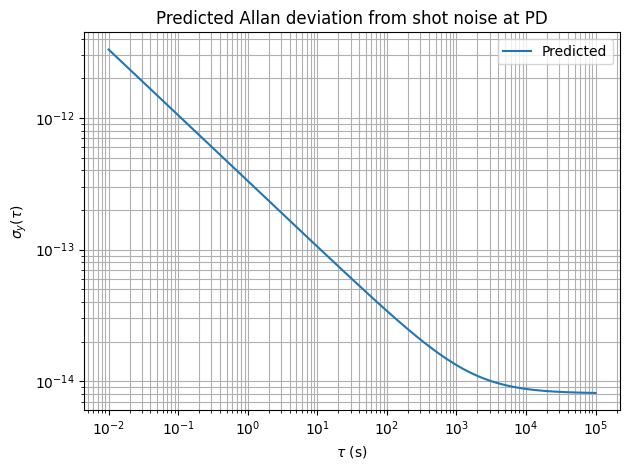

In [46]:
sigma_y_total = np.sqrt(sigma_y_shot**2 + sigma_y_back_refl**2)

plt.figure()
plt.loglog(tau, sigma_y_total, label='Predicted')
# plt.loglog(tau, sigma_y_shot_ref, label='Experimental')
plt.xlabel(r'$\tau$ (s)')
plt.ylabel(r'$\sigma_y(\tau)$')
plt.grid(True, which='both')
plt.title(f'Predicted Allan deviation from shot noise at PD')
plt.legend()
plt.tight_layout()
plt.show()